In [25]:
# ==========================================
# Environment Setup & Data Ingestion
# ==========================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

# For Reproducibility
np.random.seed(42)

# Path to the model-ready data exports (relative to this notebook)
dataset_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Dataset', 'Model_Ready_Exports')

print("=" * 60)
print("LOADING DATA & APPLYING TARGET TRANSFORMATION")
print("=" * 60)

try:
    # Load the datasets
    X_train = pd.read_parquet(os.path.join(dataset_path, 'X_train.parquet'))
    X_test = pd.read_parquet(os.path.join(dataset_path, 'X_test.parquet'))
    y_train = pd.read_parquet(os.path.join(dataset_path, 'y_train.parquet'))
    y_test = pd.read_parquet(os.path.join(dataset_path, 'y_test.parquet'))

    # Load scaler in case we need to inverse transform features later
    scaler = joblib.load(os.path.join(dataset_path, 'feature_scaler.pkl'))

    # Extract the 1D series from the y dataframes
    y_train_raw = y_train.squeeze()
    y_test_raw = y_test.squeeze()

    # Apply log1p transformation to the target variables
    y_train_log = np.log1p(y_train_raw)
    y_test_log = np.log1p(y_test_raw)

    print("✅ Datasets loaded successfully!")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train_log shape: {y_train_log.shape}")

    print("\nTarget Variable (zhvi) Summary:")
    print(f"Original y_train Mean: ${y_train_raw.mean():,.2f}")
    print(f"Log-Transformed y_train Mean: {y_train_log.mean():.4f}")

    # Display the first few rows of our training features
    print("\nFirst 5 rows of X_train:")
    display(X_train.head())

except Exception as e:
    print(f"Error loading files: {e}")
    print("Please double-check the 'dataset_path' variable.")

Mounted at /content/drive
LOADING DATA & APPLYING TARGET TRANSFORMATION
✅ Datasets loaded successfully!
X_train shape: (98532, 9)
X_test shape: (13923, 9)
y_train_log shape: (98532,)

Target Variable (zhvi) Summary:
Original y_train Mean: $193,366.02
Log-Transformed y_train Mean: 12.0586

First 5 rows of X_train:


,rent,for_sale,days_pending,price_cuts,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic,state_encoded
0,-0.786191,-0.348168,0.233897,0.129621,-0.091809,-0.204989,2.007224,-0.183597,-0.627317
1,-0.591568,-0.391177,2.527199,-0.890090,-1.169172,-0.220649,-0.127020,-0.183597,0.204456
2,-0.192740,0.944134,-1.107468,0.251143,0.529746,-0.343586,0.190462,-0.183597,-0.333845
3,-0.319452,-0.098773,-0.242071,0.493899,0.405435,-0.218287,-0.322654,-0.183597,2.712180
4,-1.097279,-0.374623,-0.415150,-0.513307,0.032502,-0.253359,0.453756,-0.183597,-0.627317


In [26]:
# ==========================================
# Train Multiple Linear Regression
# ==========================================

print("=" * 60)
print("TRAINING MULTIPLE LINEAR REGRESSION")
print("=" * 60)

# Initialize the model
mlr_model = LinearRegression()

# Fit the model using training set (predicting the log-transformed target)
mlr_model.fit(X_train, y_train_log)

# Extract and display what the model learned
print(f"Intercept (Beta_0): {mlr_model.intercept_:.4f}\n")

print("Feature Coefficients (Beta_1 to Beta_n):")
print("Note: Because features were standardized, larger absolute values indicate stronger impact.\n")

# Zip the column names with the coefficients for easy reading
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': mlr_model.coef_
})

# Sort by absolute value to see which features have the strongest impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1).reset_index(drop=True)

display(coefficients)

TRAINING MULTIPLE LINEAR REGRESSION
Intercept (Beta_0): 12.0586

Feature Coefficients (Beta_1 to Beta_n):
Note: Because features were standardized, larger absolute values indicate stronger impact.



,Feature,Coefficient
0,rent,0.205389
1,market_heat_index,0.088828
2,state_encoded,0.084938
3,space_premium,-0.076276
4,days_pending,-0.043229
5,price_cuts,0.027659
6,is_post_pandemic,0.025667
7,new_homeowner_affordability,0.022907
8,for_sale,0.006595


In [27]:
# ==========================================
# Baseline Evaluation Metrics
# ==========================================

print("=" * 60)
print("EVALUATING MLR BASELINE ON HOLDOUT SET")
print("=" * 60)

# Generate predictions on the untouched test set (in log scale)
y_pred_log = mlr_model.predict(X_test)

# Reverse the log transformation to get actual dollar values
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# Calculate Metrics

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

# MAE
mae = mean_absolute_error(y_test_actual, y_pred_actual)

# MAPE
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# R-squared
r2 = r2_score(y_test_actual, y_pred_actual)

# Rresults
print(f"Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
print(f"R-squared (R²)                 : {r2:.4f}")

EVALUATING MLR BASELINE ON HOLDOUT SET
Root Mean Squared Error (RMSE) : $74,978.28
Mean Absolute Error (MAE)      : $50,290.33
Mean Absolute Pct Error (MAPE) : 14.36%
R-squared (R²)                 : 0.8271


CHECKING GAUSS-MARKOV ASSUMPTIONS

--- Variance Inflation Factor (VIF) ---
Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.



,Feature,VIF
0,rent,1.993862
1,state_encoded,1.933829
2,market_heat_index,1.632840
3,days_pending,1.373447
4,space_premium,1.316482
5,is_post_pandemic,1.219339
6,for_sale,1.205502
7,price_cuts,1.173895
8,new_homeowner_affordability,1.076981


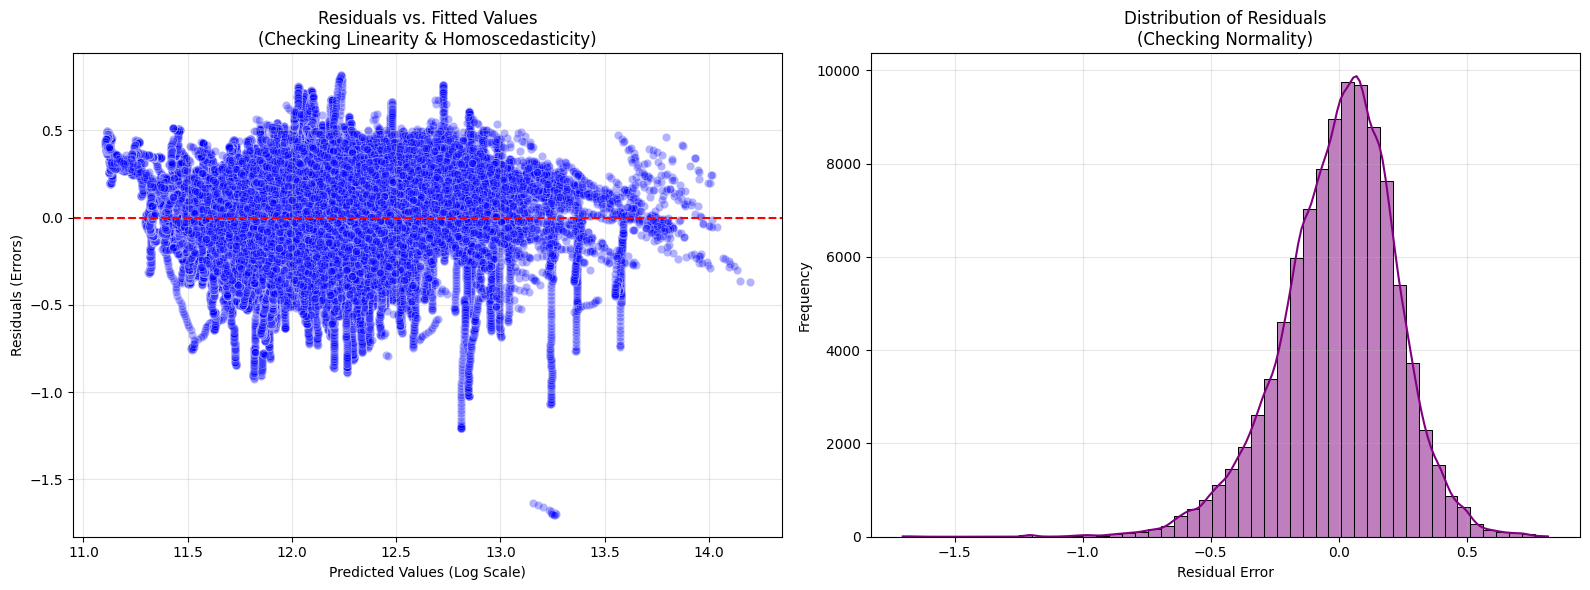

In [28]:
# ==========================================
# Gauss-Markov Diagnostics
# ==========================================
print("=" * 60)
print("CHECKING GAUSS-MARKOV ASSUMPTIONS")
print("=" * 60)

# Calculate predictions and residuals on the training set
y_train_pred_log = mlr_model.predict(X_train)
residuals = y_train_log - y_train_pred_log

# Assumption 2: Independence (Multicollinearity via VIF)
print("\n--- Variance Inflation Factor (VIF) ---")
print("Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.\n")

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
display(vif_data)

# Visual Diagnostics Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Assumption 1 & 3: Linearity and Homoscedasticity (Residuals vs Fitted)
sns.scatterplot(x=y_train_pred_log, y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values\n(Checking Linearity & Homoscedasticity)')
axes[0].set_xlabel('Predicted Values (Log Scale)')
axes[0].set_ylabel('Residuals (Errors)')
axes[0].grid(True, alpha=0.3)

# Assumption 4: Normality of Residuals (Distribution Plot)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=50)
axes[1].set_title('Distribution of Residuals\n(Checking Normality)')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# Reproducibility Export & Handoff
# ==========================================
print("=" * 60)
print("EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS")
print("=" * 60)

# Save the trained model
model_save_path = os.path.join(dataset_path, "mlr_model_final.joblib")
joblib.dump(mlr_model, model_save_path)
print(f"Model saved successfully to: {model_save_path}")

# Create a results dictionary for reproducibility
results_summary = {
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": round(r2, 4),
        "rmse_test": round(rmse, 2),
        "mae_test": round(mae, 2),
        "mape_test_pct": round(mape, 2)
    },
    "model_parameters": {
        "intercept_log_scale": round(mlr_model.intercept_, 4),
        "features_used": list(X_train.columns)
    },
    "random_state": 42
}

# Save the results dictionary to JSON
summary_path = os.path.join(dataset_path, "mlr_baseline_summary.json")
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"Baseline results summary saved to: {summary_path}\n")

# 4. Display the final JSON output for confirmation
print("Final Exported Results:")
print(json.dumps(results_summary, indent=4))

EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS
Model saved successfully to: /content/drive/MyDrive/ML Project/Dataset/mlr_model_final.joblib
Baseline results summary saved to: /content/drive/MyDrive/ML Project/Dataset/mlr_baseline_summary.json

Final Exported Results:
{
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": 0.8271,
        "rmse_test": 74978.28,
        "mae_test": 50290.33,
        "mape_test_pct": 14.36
    },
    "model_parameters": {
        "intercept_log_scale": 12.0586,
        "features_used": [
            "rent",
            "for_sale",
            "days_pending",
            "price_cuts",
            "market_heat_index",
            "new_homeowner_affordability",
            "space_premium",
            "is_post_pandemic",
            "state_encoded"
        ]
    },
    "random_state": 42
}
